In [15]:
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import shutil

from tqdm import tqdm, trange

from pathlib import Path
import ants
from nilearn.image import resample_to_img, load_img
import seaborn as sns

plt.rcParams['axes.grid'] = False

plt.rcParams['font.family'] = 'Arial'

In [16]:
PLOT_PARAMS = dict(bbox_inches='tight', transparent=True, dpi=600)

PLOT_PATH = Path('../plots')
DATA_PATH = Path('../data')
RESULTS_PATH = Path('../results')

N_CLUSTERS_LIST = list(range(2, 7))

# Copy Internal Validity Index File

In [17]:
for folder in (RESULTS_PATH / 'cbptools').iterdir():
    from_file = folder / 'individual' / 'internal_validity.tsv'
    to_file = RESULTS_PATH / f'internal_validity/{folder.name}.tsv'
    shutil.copy(from_file, to_file)

In [18]:
def plot(data):

    # key, label, direction, marker, color, darkened_color
    # y_lim, y_ticks, ax_cut_pos
    params = [('silhouette_score', 'Silhouette Coefficient', '^', '#9B59B6', '#6c3f7f', (0, 0)),
              ('davies_bouldin_score', 'Davies Bouldin Index', 'o', '#1ABC9C', '#128973', (1, 1),), ]


    fig, ax1 = plt.subplots(figsize=(5, 2.5))
    ax2 = ax1.twinx()
    axes = [ax1, ax2]

    # plot scores: lines and points
    x, d = N_CLUSTERS_LIST, 0.5
    for i, ax in enumerate(axes):
        (key, label, marker, color, darkened_color, ax_cut_pos) = params[i]

        sns.pointplot(data=data, x='n_clusters', y=key, color=color, ax=ax)

        # set up axis
        ax.set_ylabel(label, color=darkened_color, fontsize=10)
        ax.tick_params(axis='y', colors=darkened_color)
        ax.set_xlabel('')

        # add cut in axis
        kwargs = dict(markersize=12, linestyle="none", color=darkened_color, mec=color, mew=1, clip_on=False)
        ax.plot(ax_cut_pos, [0.02, 0.05], marker=[(-1, d), (1, -d)], transform=ax2.transAxes, **kwargs)

    # plot settings
    ax2.spines['left'].set_color(params[0][-2])
    ax2.spines['left'].set_linewidth(2)
    ax1.tick_params(axis='y', width=2)

    ax2.spines['right'].set_color(params[1][-2])
    ax2.spines['right'].set_linewidth(2)
    ax2.tick_params(axis='y', width=2)

    ax2.spines['bottom'].set_color('black')

    ax1.spines['top'].set_visible(False)
    ax2.spines['top'].set_visible(False)

    ax1.spines['bottom'].set_visible(False)
    ax2.spines['bottom'].set_visible(False)
    ax2.set_xlim(-0.8, 4.8)
    return fig



../results/internal_validity/HCP_YA_age_22_35_resting.tsv
../results/internal_validity/dHCP_PCW_20_45_resting.tsv
../results/internal_validity/HCP_A_age_36_60_resting.tsv
../results/internal_validity/HCP_A_age_61_100_resting.tsv
../results/internal_validity/HCP_D_age_05_11_resting.tsv
../results/internal_validity/HCP_D_age_12_21_resting.tsv
../results/internal_validity/HCP_YA_age_22_35_DTI.tsv
../results/internal_validity/HCP_YA_age_22_35_movie.tsv
../results/internal_validity/HCP_YA_age_22_35_resting_3T.tsv
../results/internal_validity/HCP_YA_age_22_35_resting_7T.tsv
../results/internal_validity/Inhouse_age_18_30_DTI.tsv
../results/internal_validity/Inhouse_age_18_30_resting.tsv
../results/internal_validity/Primate.tsv
../results/internal_validity/BCP_age_0_3_resting.tsv


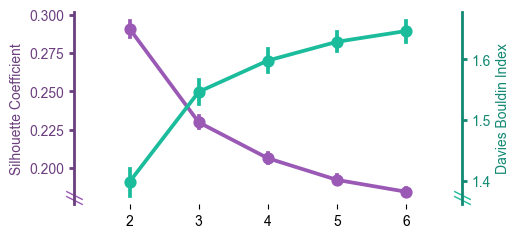

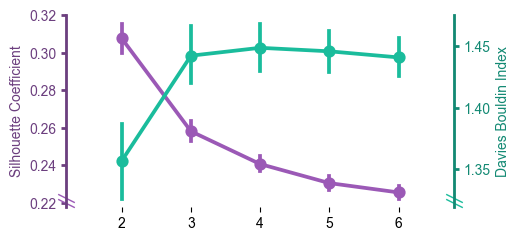

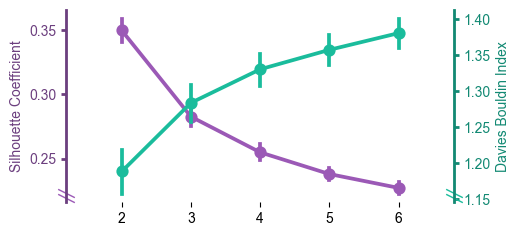

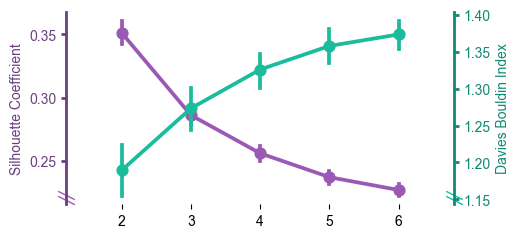

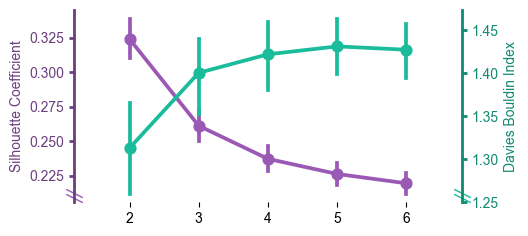

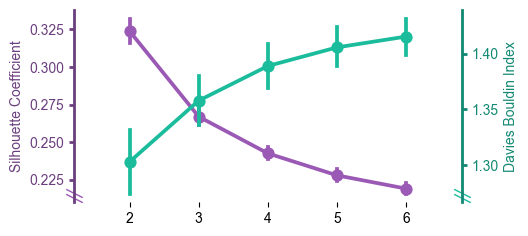

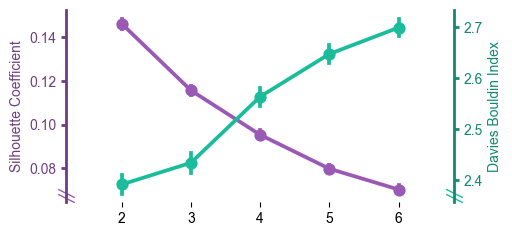

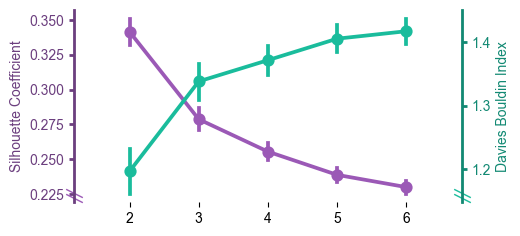

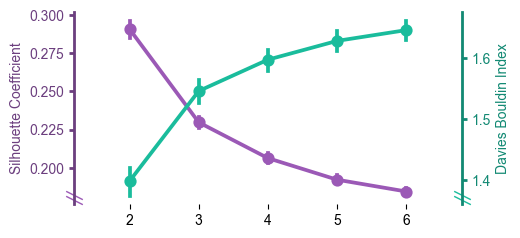

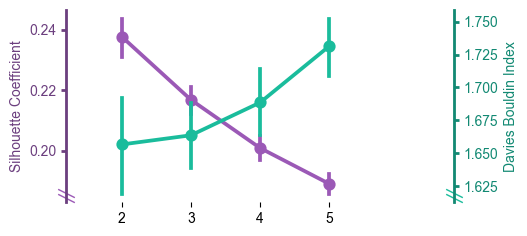

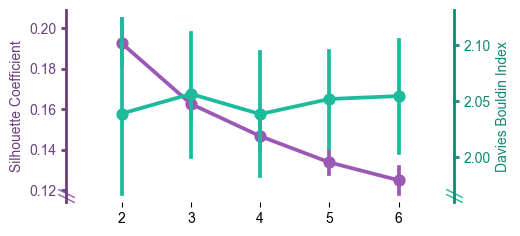

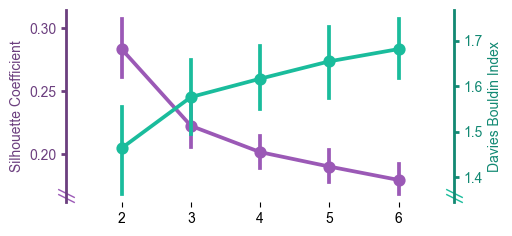

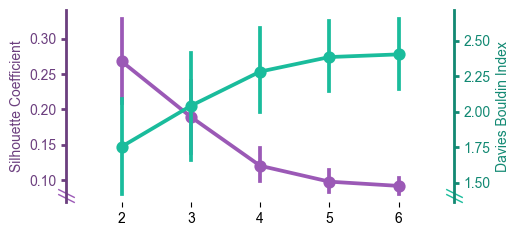

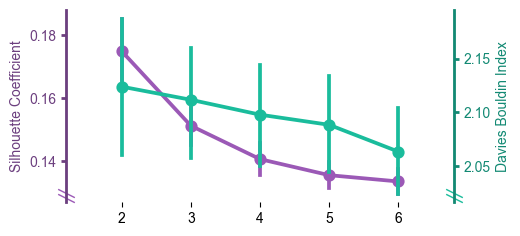

In [22]:
for  file in (RESULTS_PATH /'internal_validity').iterdir():
    print(file)
    data = pd.read_csv(file, sep='\t')

    # if file.stem == 'HCP_YA_age_22_35_7Tresting':
    #     df_list = []
    #     for participant_id, df in data.groupby(['participant_id']):
    #         new_row = df.iloc[-1] + df.diff().iloc[-1]
    #         df = pd.concat([df, new_row.to_frame().T], axis=0)
    #         df_list.append(df)
    #
    #     data = pd.concat(df_list)

    fig = plot(data)
    # break
    # fig.savefig(PLOT_PATH / f'internal_validity/{file.stem}.svg', **PLOT_PARAMS)
    # fig.savefig(PLOT_PATH / f'internal_validity/{file.stem}.png', **PLOT_PARAMS)

# Copy Nifti File

## dHCP

In [9]:
top_path = Path("/home/guoqiu/NAS/HCPd/CBPtool/dHCP/results/test2/group")
assert top_path.exists(), 'DATABASE_PATH does not exist!'

# example input file:
# input_file = top_path / "3clusters/labeled_roi.nii.gz"
for n_cluster in  N_CLUSTERS_LIST:
    input_file = RESULTS_PATH / f'cbptools/dHCP_PCW_20_45_resting/group/3clusters{n_cluster}/labeled_roi.nii.gz'
    output_file = RESULTS_PATH / 'nii' / f'dHCP_PCW_20_45_resting_K{n_cluster}.nii.gz'

    # step1: to baby template space
    baby_template_file = "/home/guoqiu/NAS/Baby_Brain/dHCP/Infant_registration_2step_extdhcp40wk/week40_T2w.nii.gz"
    baby_input_nib_img = resample_to_img(
        source_img=input_file,
        target_img=baby_template_file,
        interpolation='nearest')

    # step 2: invert to MNI152
    baby_input_nib_img = ants.from_nibabel(baby_input_nib_img)
    MNI152_template_file = "/home/guoqiu/NAS/Baby_Brain/dHCP/Infant_registration_2step_extdhcp40wk/mni_icbm152_t1_tal_nlin_asym_09a_brain.nii"
    MNI152_template_ants_img = ants.image_read(MNI152_template_file)
    MNI152_affine = "/home/guoqiu/NAS/HCPd/CBPtool/dHCP/mask/mni2dhcp_invaffine.mat"
    MNI_input_ants_img = ants.apply_transforms(
        moving=baby_input_nib_img,
        fixed=MNI152_template_ants_img,
        whichtoinvert=[True],
        interpolator='nearestNeighbor',
        transformlist=[MNI152_affine])

    # step 3: to vmpfc
    vmpfc_mask_file = "/home/guoqiu/NAS/HCPd/CBPtool/codes/k3_vmpfc_mask_binary.nii.gz"
    vmpfc_input_nib_img = resample_to_img(MNI_input_ants_img.to_nibabel(), vmpfc_mask_file, interpolation='nearest')

    vmpfc_input_nib_img.to_filename(output_file)
    print(f'from {input_file} \nto {output_file}')


## BCP

In [13]:
top_path = Path('/home/guoqiu/NAS/Dep/Connectome_based_parcellation/results/BCP')
assert top_path.exists(), 'DATABASE_PATH does not exist!'
# example input file:
# input_file = top_path / "3clusters/labeled_roi.nii.gz"
for input_file in top_path.rglob('*clusters/labeled_roi.nii.gz'):
    k_num = str(input_file.relative_to(top_path))[0]
    output_file = RESULTS_PATH / 'nii' / f'BCP_age_0_3_resting_K{k_num}.nii.gz'

    # step1: baby template space
    baby_template_file = '/home/guoqiu/NAS/Dep/BCP/BCP_from_Helab/UNC-BCP_4D_Infant_Brain_Volumetric_Atlas/6Month/BCP-06M-T1.nii.gz'
    baby_input_nib_img = resample_to_img(
        source_img=input_file,
        target_img=baby_template_file,
        interpolation='nearest')

    # step 2: baby template invert transform to MNI152
    baby_input_nib_img = ants.from_nibabel(baby_input_nib_img)
    MNI152_template_file = "/home/guoqiu/NAS/Baby_Brain/dHCP/Infant_registration_2step_extdhcp40wk/mni_icbm152_t1_tal_nlin_asym_09a_brain.nii"
    MNI152_template_ants_img = ants.image_read(MNI152_template_file)
    transform_list = ants.registration(
        fixed=ants.image_read(baby_template_file),
        moving=MNI152_template_ants_img,
        type_of_transform='SyN')['invtransforms']
    MNI_input_ants_img = ants.apply_transforms(
        moving=baby_input_nib_img,
        fixed=MNI152_template_ants_img,
        interpolator='nearestNeighbor',
        transformlist=transform_list)

    # step 3: MNI152 to vmpfc
    vmpfc_mask_file = "/home/guoqiu/NAS/HCPd/CBPtool/codes/k3_vmpfc_mask_binary.nii.gz"
    vmpfc_input_nib_img = resample_to_img(MNI_input_ants_img.to_nibabel(), vmpfc_mask_file, interpolation='nearest')

    vmpfc_input_nib_img.to_filename(output_file)
    print(f'from {input_file} \nto {output_file}')


## Others

In [ ]:
data_folder = Path('/home/guoqiu/NAS/Dep/Connectome_based_parcellation/results/')
to_folder = RESULTS_PATH / 'nii_by_label'
for cluster_k in trange(2, 7):
    file_name_mapping = {
        'HCP_D_age_05_11_resting': data_folder / f'HCP_D/HCP_D_143/{cluster_k}clusters/labeled_roi.nii.gz',
        'HCP_D_age_12_21_resting': data_folder / f'HCP_D/HCP_D_144/{cluster_k}clusters/labeled_roi.nii.gz',
        'HCP_YA_age_22_35_resting': data_folder / f'HCP_YA/REST/{cluster_k}clusters/labeled_roi.nii.gz',
        'HCP_A_age_36_60_resting': data_folder / f'HCP_A/HCP_A_720/{cluster_k}clusters/labeled_roi.nii.gz',
        'HCP_A_age_61_100_resting': data_folder / f'HCP_A/HCP_A_721/{cluster_k}clusters/labeled_roi.nii.gz',
        'HCP_YA_age_22_35_DTI': data_folder / f'HCP_YA/DTI/{cluster_k}clusters/labeled_roi.nii.gz',
        'HCP_YA_age_22_35_movie': data_folder / f'HCP_7T/New_MOVIE/HCP_7T_MOVIE_clips_n172/{cluster_k}clusters/labeled_roi.nii.gz',
        'Inhouse_18_30_resting': data_folder / f'Wanglab_VMPFC_Dataset/REST/{cluster_k}clusters/labeled_roi.nii.gz',
        'HCP_YA_age_22_35_7Tresting': data_folder / f'HCP_7T/REST/{cluster_k}clusters/labeled_roi.nii.gz',
        'Inhouse_18_30_DTI': data_folder / f'Wanglab_VMPFC_Dataset/DTI/{cluster_k}clusters/labeled_roi.nii.gz',
    }

    for name, from_file in file_name_mapping.items():
        to_file = RESULTS_PATH / f'nii/{name}_K{cluster_k}.nii.gz'
        shutil.copy(from_file, to_file)



# Nifti to Gifti

In [28]:
# Split Labels
to_folder = RESULTS_PATH / 'nii_by_label'
for from_file in (RESULTS_PATH / 'nii').iterdir():
    img = nib.load(from_file)
    img_data = np.round(img.get_fdata())

    cluster_k = int(from_file.stem.split('_K')[1][0])
    name = from_file.name.removesuffix('.nii.gz')
    for label_i in range(1, cluster_k + 1):
        label_img_data = (img_data == label_i).astype(int)
        label_img = nib.Nifti1Image(label_img_data, affine=img.affine, dtype=np.int8)
        nib.save(label_img, to_folder / f'{name}_K{cluster_k}_label{label_i}.nii.gz')

In [29]:
surf_file = "/home/guoqiu/guoqiu/Database/HCP_S1200_GroupAvg_v1/S1200.L.midthickness_MSMAll.32k_fs_LR.surf.gii"

from_file_list = list((RESULTS_PATH / 'nii_by_label').iterdir())
for from_file in tqdm(from_file_list):
    from_file_str = str(from_file.resolve())
    to_file_str = (from_file_str
                   .replace('nii_by_label', 'gii_by_label')
                   .replace('.nii.gz', '.func.gii'))
    shell_code = f'wb_command -volume-to-surface-mapping "{from_file_str}" "{surf_file}" "{to_file_str}" -enclosing'
    os.system(shell_code)